20.602041703090325
20.684
A condição de estabilidade foi satisfeita.
lambda = 0.495138157616275


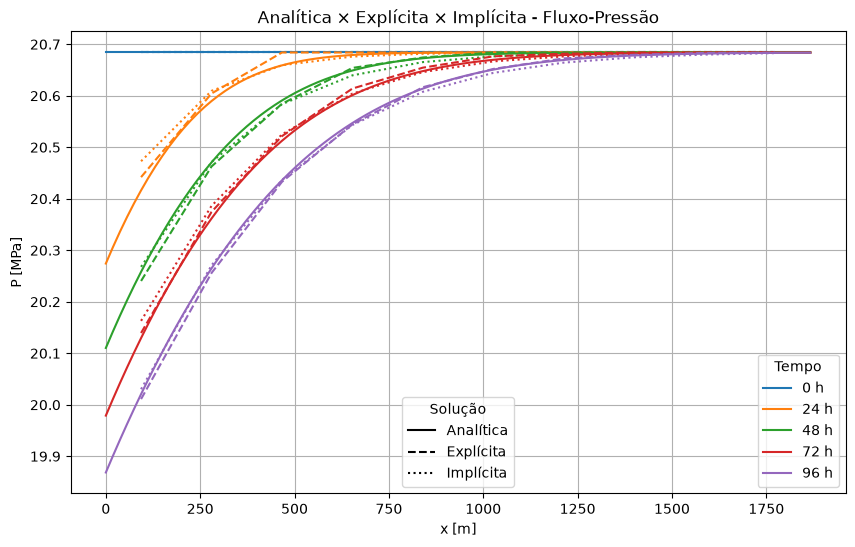

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_FP import linear_trans_1d_FP
from mdf.explicita import explicita_1d_FP
from mdf.implicita import implicita_1d_FP


# parâmetros

p0 = 20.684e6
Pe = p0

A_R = 3484800
L = np.sqrt(A_R)

qw = 4.968e-3

k = 339 * 9.869233e-16
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

h = 4.572
A = h * L

t_h = 96                  # tempo final [h]
t_final = t_h * 3600      # tempo final [s]

eta = k / (phi * ct * mu)


# solução analítica

x_an, t_an, X, T, P_an = linear_trans_1d_FP(p0, qw, L, k, A, mu, eta, t_final)


# malha numérica

nx = 10
nt = 10


# solução explícita

x_exp, t_exp, P_exp, lambd_exp = explicita_1d_FP(p0, Pe, -qw, h, L, k, phi, ct, mu, t_final, nx, nt)

print("lambda =", lambd_exp)


# solução implícita

metodo = "TDMA"  # opções: "TDMA", "Gauss", "Jacobi" ou "Scipy"

x_imp, t_imp, P_imp, lambd_imp = implicita_1d_FP(p0, Pe, -qw, h,  L, k, phi, ct, mu, t_final, nx, nt, metodo=metodo)


# comparação das soluções

tempos_escolhidos = np.linspace(0, t_h, 5)

plt.figure(figsize=(10, 6))

cores = []

for tempo in tempos_escolhidos:

    t_escolhido = tempo * 3600

    i_an = np.argmin(np.abs(t_an - t_escolhido))
    i_exp = np.argmin(np.abs(t_exp - t_escolhido))
    i_imp = np.argmin(np.abs(t_imp - t_escolhido))

    # solução analítica
    linha, = plt.plot(x_an, P_an[i_an, :] / 1e6, "-")

    cor = linha.get_color()
    cores.append(cor)

    # solução explícita
    plt.plot(x_exp, P_exp[i_exp, :] / 1e6, "--", color=cor)

    # solução implícita
    plt.plot(x_imp, P_imp[i_imp, :] / 1e6, ":", color=cor)


plt.xlabel("x [m]")
plt.ylabel("P [MPa]")
plt.title("Analítica × Explícita × Implícita - Fluxo-Pressão")
plt.grid()


# legenda dos tempos

linhas_tempo = []

for tempo, cor in zip(tempos_escolhidos, cores):

    linha_tempo, = plt.plot([], [], color=cor, label=f"{tempo:.0f} h")

    linhas_tempo.append(linha_tempo)


legenda_tempo = plt.legend(handles=linhas_tempo, title="Tempo", loc="lower right")

plt.gca().add_artist(legenda_tempo)


# legenda das soluções

analitica, = plt.plot([], [], "k-", label="Analítica")
explicita, = plt.plot([], [], "k--", label="Explícita")
implicita, = plt.plot([], [], "k:", label="Implícita")

plt.legend(
    handles=[analitica, explicita, implicita],
    title="Solução",
    loc="lower center"
)

plt.show()